**IMDB Binary Text Classification:**

**Project Description:**

This project contains 25,000 movie reviews for training and 25,000 movie reviews for testing. Its a binary sentiment classification dataset for classifying the IMDB reviews.

**Project Objective:**

The main objective of the project is to classify whether a review is positive or negative. I have used the following deep learning models to classify the sentiment of a review. I have chosen the best model based on the accuracy and loss values, and implemented the best model on the test set. Have also hyperparameter tuning for BiLSTM, CNN, and GRU models.

1. Baseline Model
2. BiLSTM
3. BiLSTM Tuned
4. CNN
5. CNN Tuned
6. GRU
7. GRU Tuned

**Data Description:**

This dataset has reviews and a label (0 or 1 ) to indicate if they are positive or negative.

0-Negative
1-Positive

Reviews in the dataset:
25000 - Train
25000 - Test

I have split the 25000 reveiws ib the train folder to 20000 for traning and 5000 for validation.

Each review is in a separate file.

In [1]:
!nvidia-smi

Sat Feb 21 20:13:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  5137k      0  0:00:15  0:00:15 --:--:-- 12.0M


In [3]:
!tar -xzf aclImdb_v1.tar.gz

In [4]:
!ls

aclImdb  aclImdb_v1.tar.gz


In [5]:
!ls aclImdb/train

labeledBow.feat  pos	unsupBow.feat  urls_pos.txt
neg		 unsup	urls_neg.txt   urls_unsup.txt


In [6]:
!ls aclImdb/test

labeledBow.feat  neg  pos  urls_neg.txt  urls_pos.txt


In [7]:
!cat aclImdb/train/pos/6248_7.txt

Being an Austrian myself this has been a straight knock in my face. Fortunately I don't live nowhere near the place where this movie takes place but unfortunately it portrays everything that the rest of Austria hates about Viennese people (or people close to that region). And it is very easy to read that this is exactly the directors intention: to let your head sink into your hands and say "Oh my god, how can THAT be possible!". No, not with me, the (in my opinion) totally exaggerated uncensored swinger club scene is not necessary, I watch porn, sure, but in this context I was rather disgusted than put in the right context.<br /><br />This movie tells a story about how misled people who suffer from lack of education or bad company try to survive and live in a world of redundancy and boring horizons. A girl who is treated like a whore by her super-jealous boyfriend (and still keeps coming back), a female teacher who discovers her masochism by putting the life of her super-cruel "lover" 

In [8]:
!rm -r aclImdb/train/unsup

In [9]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers

from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding,GRU,Dense,Bidirectional
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import keras_tuner as kt
from sklearn.metrics import roc_curve, auc

import tensorflow_hub as hub
import tensorflow_text as text

2026-02-21 20:14:45.571878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771704885.781155      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771704885.844376      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771704886.376888      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771704886.376934      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771704886.376936      55 computation_placer.cc:177] computation placer alr

In [11]:
raw_train_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='training',seed=42)

raw_val_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='validation',seed=42)

raw_test_ds = keras.utils.text_dataset_from_directory("aclImdb/test",batch_size=32)

print("\n")
print(f"Number of batches in raw_train_ds:{raw_train_ds.cardinality()}")
print(f"Number of batches in raw_val_ds:{raw_val_ds.cardinality()}")
print(f"Number of batches in raw_test_ds:{raw_test_ds.cardinality()}")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1771704919.175305      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


Number of batches in raw_train_ds:625
Number of batches in raw_val_ds:157
Number of batches in raw_test_ds:782


**Exploratory Data Analysis**

EDA is done only on the training data. Not on the validation and test set.

In [12]:
#Light Cleaning for EDA

def clean_text_light(text):
  text = re.sub(r"<br\s*/?","",text) #remove HTML tags
  text = re.sub(r"[^a-zA-Z\s]","",text) # remove punctuation and numbers
  text = re.sub(r"\s+","",text) #multiple spaces

  return text.lower().strip()

In [13]:
texts = []
labels = []

for text_batch,label_batch in raw_train_ds:
  for text,label in zip(text_batch.numpy(),label_batch.numpy()):
    texts.append(text.decode("utf-8"))
    labels.append(int(label))

In [15]:
train_df = pd.DataFrame({"review":texts,"label":labels})
train_df['clean_review'] = train_df['review'].apply(clean_text_light)
train_df.head()

,review,label,clean_review
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...


In [16]:
train_df.shape

(20000, 3)

In [17]:
train_df['label'].value_counts()

label
0    10038
1     9962
Name: count, dtype: int64

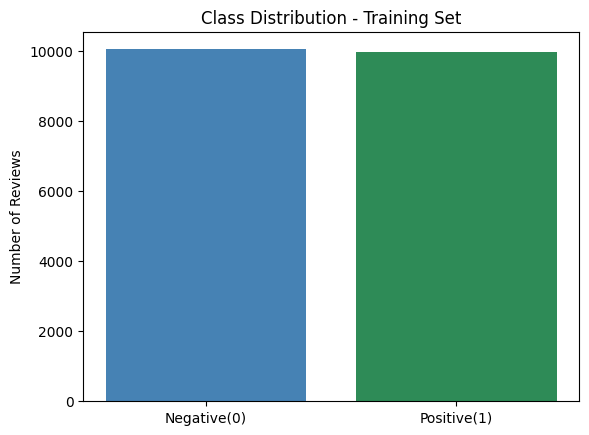



Class Percentage Distribution
0    50.19
1    49.81
dtype: float64


In [18]:
#Class Distribution:

plt.bar(['Negative(0)','Positive(1)'],[10038,9962],color=['steelblue','seagreen'])
plt.title('Class Distribution - Training Set')
plt.ylabel('Number of Reviews')

plt.show()

#Percentage distribution
print("\n")
print("Class Percentage Distribution")
counts = pd.Series({0:10038,1:9962})
percentages = counts/counts.sum() * 100

print(percentages)

We can see from the above that the class is balanced.

Negative Sentiment/Reviews - 10038
Positive Sentiment/Reviews - 9962

This confirms there is no class imbalance.

In [19]:
#Check for Missing or Empty Reviews

#Missing reviews

train_df['review'].isna().sum()

np.int64(0)

In [20]:

#Check for empty reviews or whitespaces

empty_str = (train_df['review'].str.strip()=="").sum()
print(f"There are {empty_str} empty string")

There are 0 empty string


We can conclude from the above that there are no missing values and empty reviews.

**Text Length Analysis:**
**Word/Character Count Distribution:**

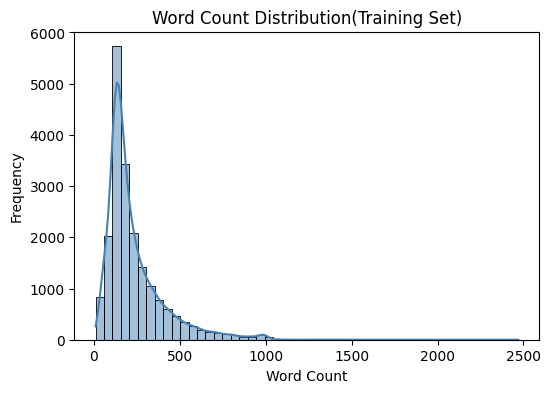

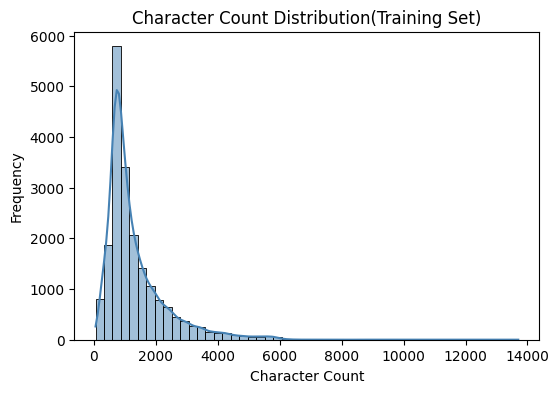

In [21]:
#Calculate Word count and character count

train_df['word_count']=train_df['review'].apply(lambda x:len(x.split()))
train_df['char_count'] = train_df['review'].apply(lambda x:len(x))

#Word Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['word_count'],bins=50,kde=True,color='steelblue')
plt.title('Word Count Distribution(Training Set)')
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#Character Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['char_count'],bins=50,kde=True,color='steelblue')
plt.title('Character Count Distribution(Training Set)')
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

From the above 2 plots, we can see that most of the reviews have 100 to 200 words.Reviews greater than 500 words are very less. This means everyone prefers to write short reviews.

The character count plot also implies the same.

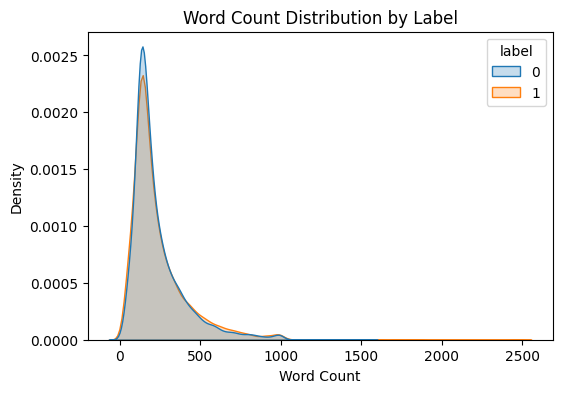

In [22]:
#Length Distributions Comparisons - Positive vs Negative reviews

plt.figure(figsize=(6,4))
sns.kdeplot(data=train_df,x='word_count',hue='label',fill=True)
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.show()

Most of the reviews whether positive or negative,are relatively short , around 200 to 400 words.Since both the curves overlap, this is not a strong review of the label(0 or 1).Very few reviews exceed 1000 words.

**Outlier Detection:**

In [23]:
#Identify Outliers

low_word_threshold = train_df['word_count'].quantile(0.01)
high_word_threshold = train_df['word_count'].quantile(0.99)

outliers_short = train_df[train_df['word_count'] <= low_word_threshold]
outliers_long = train_df[train_df['word_count'] >= high_word_threshold]

print("Very Short Reviews(bottom 1%)",outliers_short.shape[0])
print("Very long Reviews(top 1%)",outliers_long.shape[0])

print("\nExample of very short reviews")
print(outliers_short['review'].head(1).to_list())

print("\nExample of very long reviews")
print(outliers_long['review'].head(1).to_list())

Very Short Reviews(bottom 1%) 218
Very long Reviews(top 1%) 201

Example of very short reviews
['Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.']

Example of very long reviews
['I\'m going to write about this movie and about "Irreversible" (the (in)famous scene in it). So you are warned, if you haven\'t seen the movie yet. This are just my thoughts, why I think the movie fails (in the end - pun intended).<br /><br />Acting wise, Rosario Dawson is really good and almost conveys portraying someone almost a decade younger (a teenager in other words). The villain guy is good, but loses his "evil" touch right before the end. If he really never changes, then why would he let a woman tie him up? He wouldn\'t, period. Then we also have the bartender/2nd rape Dude. Actually I don\'t think you would need him. At least not for the 2nd rape, but more about that later on.<br /><br />Let\'s reprise the story. Rosario

<Figure size 1200x500 with 0 Axes>

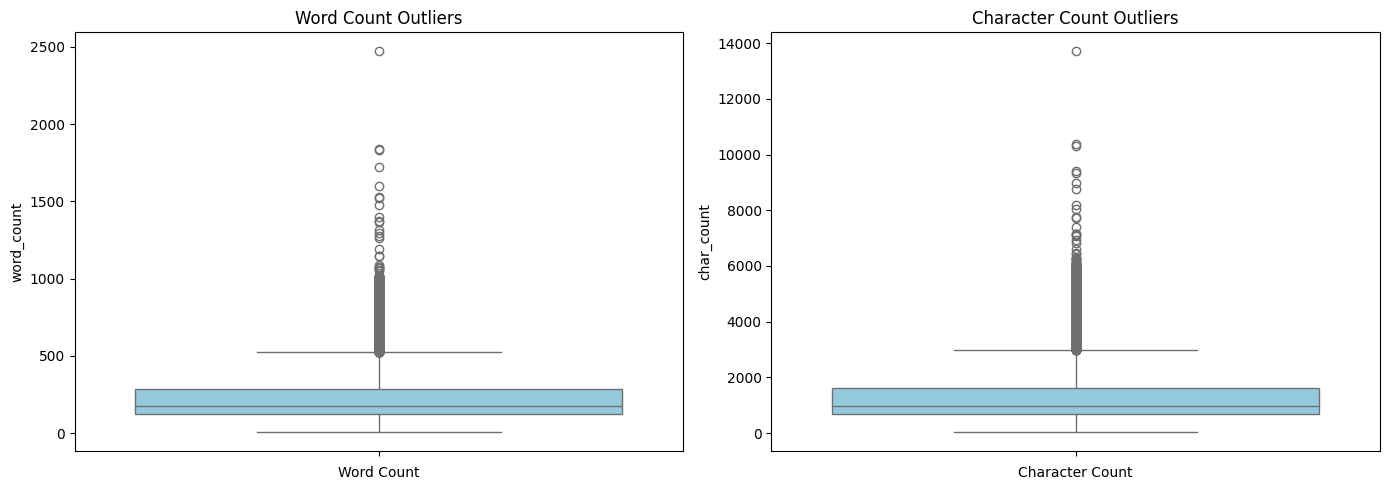

In [24]:
plt.figure(figsize=(12,5))

fig,axes = plt.subplots(1,2,figsize=(14,5))

#Word Count Boxplot
sns.boxplot(y=train_df['word_count'],ax=axes[0],color='skyblue')
axes[0].set_title("Word Count Outliers")
axes[0].set_xlabel('Word Count')

#Character Count boxplot
sns.boxplot(y=train_df['char_count'],ax=axes[1],color='skyblue')
axes[1].set_title("Character Count Outliers")
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.show()


Word Count Outlier plot reveals that most of the words were between ~50  and within ~500.Dots above the whiskers are outliers - reviews that are usually long up to 2500 words.It might have excessive repetition etc.

Character Count Outlier plot reveals the same structure like word count.Most reviews are under ~ 4000 characters.But ouliers stretch to 14000 characters. This might have html tags,punctuation etc. which will be removed during data processing.

#Vocabulary-Level EDA

This shows the top frequent 20 words in Positive and Negative reviews.

From the above 2 plots,we can see that the word 'The' has maximum count for both positive and negative reviews.

In [27]:
train_df.head()

,review,label,clean_review,word_count,char_count
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...,135,751
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...,205,1180
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...,125,702
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...,342,1969
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...,269,1511


In [25]:
#Stopword Frequency

train_df['tokens']

all_words = [word for tokens in train_df['tokens'] for word in tokens]
stopword_counts = Counter([word for word in all_words if word in stop_words])
top_stopwords = stopword_counts.most_common(20)
words,counts = zip(*top_stopwords)

plt.figure(figsize=(6,4))
sns.barplot(x=list(words),y=list(counts),palette='gray')
plt.title('Top Stopwords')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

KeyError: 'tokens'

In [27]:
#Rare words count

word_freq =  [word for tokens in train_df['tokens'] for word in tokens]
word_freq_list = Counter(word_freq)

rare_words = [word for word,count in word_freq_list.items() if count==1]
print(f"Total length of rare words: {len(rare_words)}")
print(f"Total Vocabulary size:{len(word_freq)}")

Total length of rare words: 24062
Total Vocabulary size:4609286


**Word Cloud:**

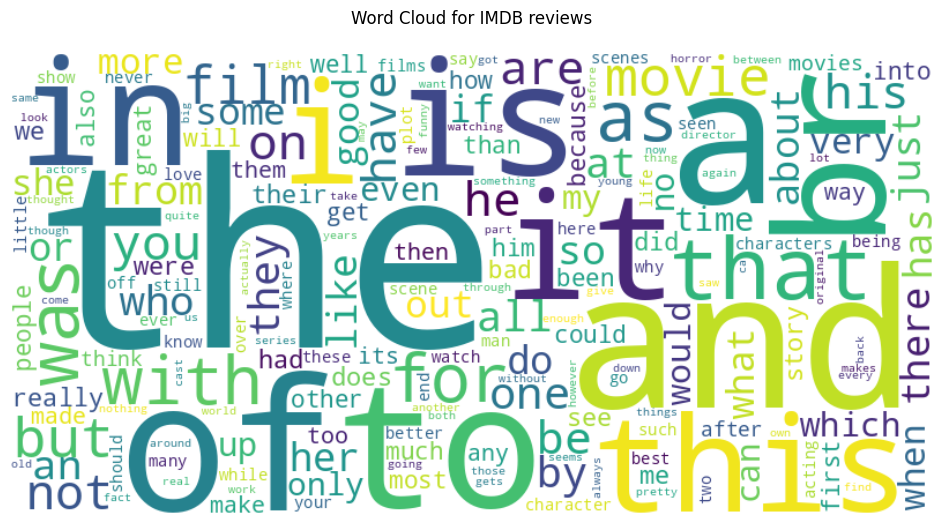

In [28]:
word_freq = Counter(all_words)

wordcloud = WordCloud(width=800,height=400,background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for IMDB reviews\n")
plt.show()


**N-grams:**

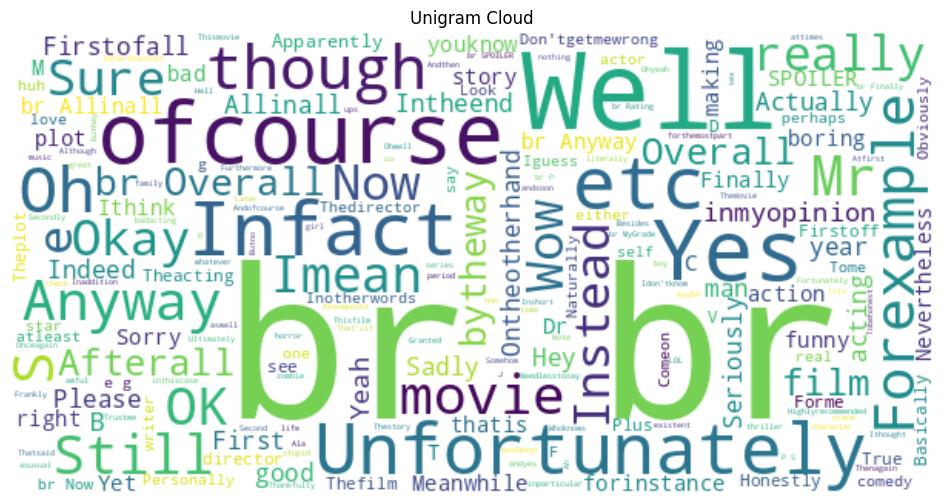

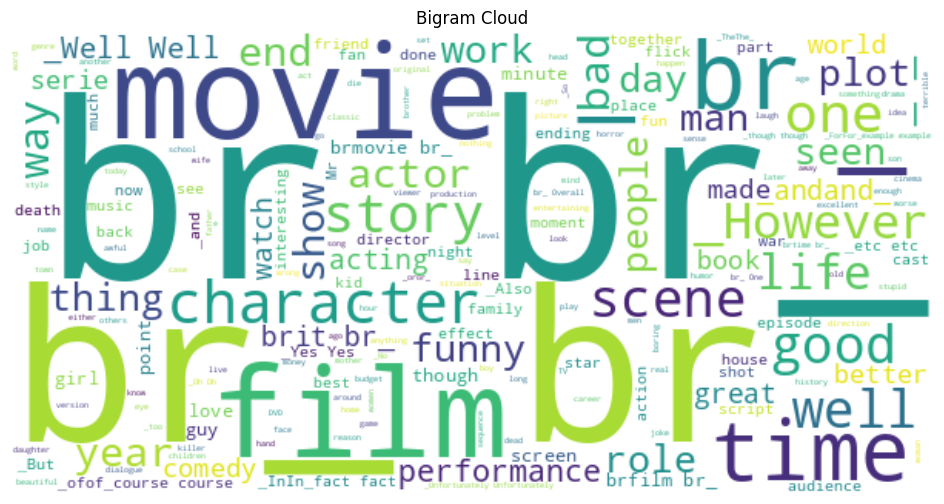

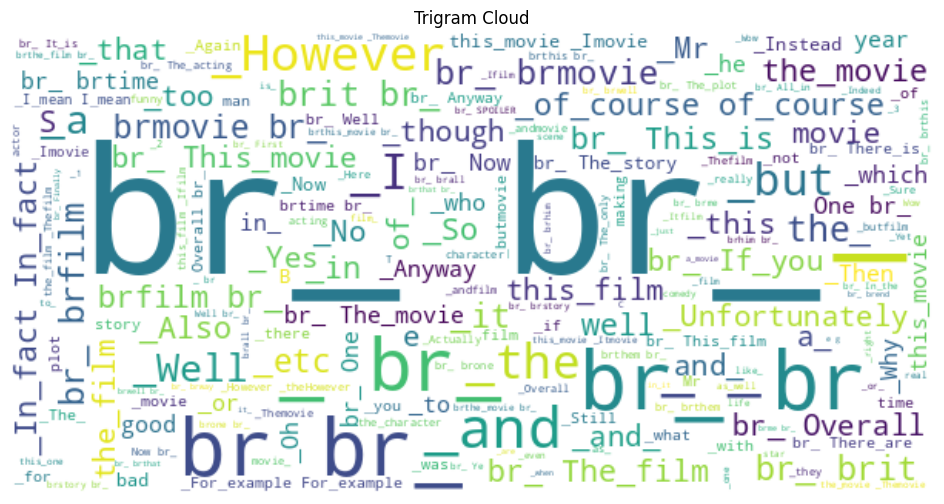

In [29]:
#N-grams for the entire training dataset

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

unigrams = generate_all_ngrams(train_df['review'],1)
bigrams = generate_all_ngrams(train_df['review'],2)
trigrams = generate_all_ngrams(train_df['review'],3)

unigram_counts = Counter(unigrams)
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

unigram_text = "".join(["_".join(u) for u in unigrams])
bigram_text = "".join(["_".join(b) for b in bigrams])
trigram_text = "".join(["_".join(t) for t in trigrams])

def show_cloud(text,title):
  wc = WordCloud(width=600,height=300,background_color='white').generate(text)
  plt.figure(figsize=(12,6))
  plt.imshow(wc,interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

show_cloud(unigram_text,"Unigram Cloud")
show_cloud(bigram_text,"Bigram Cloud")
show_cloud(trigram_text,"Trigram Cloud")

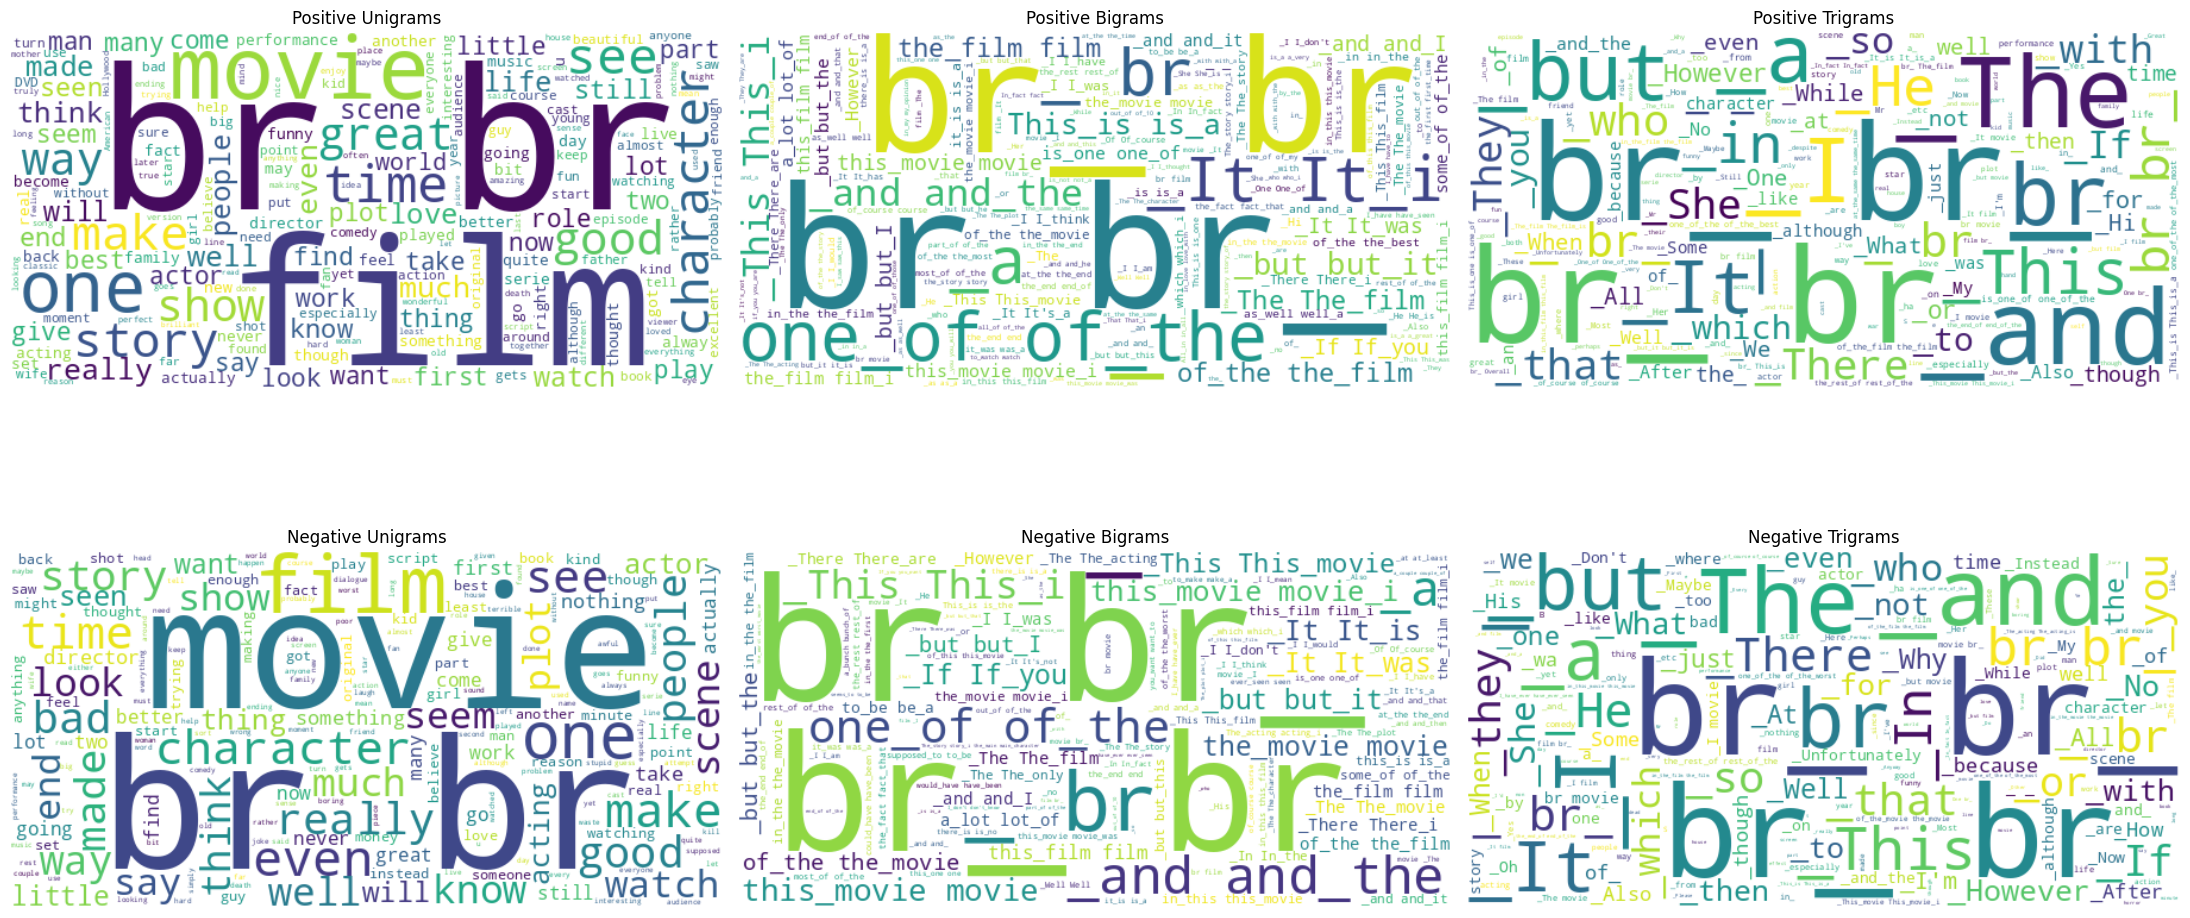

In [30]:
#Separate N-grams for positive and negative reviews

pos_reviews = train_df[train_df['label']==1]['review']
neg_reviews = train_df[train_df['label']==0]['review']

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

pos_unigrams = generate_all_ngrams(pos_reviews,1)
pos_bigrams = generate_all_ngrams(pos_reviews,2)
pos_trigrams = generate_all_ngrams(pos_reviews,3)

neg_unigrams = generate_all_ngrams(neg_reviews,1)
neg_bigrams = generate_all_ngrams(neg_reviews,2)
neg_trigrams = generate_all_ngrams(neg_reviews,3)

def ngrams_to_text(ngrams):
  return " ".join(["_".join(t) for t in ngrams])

pos_uni_text = ngrams_to_text(pos_unigrams)
pos_bi_text = ngrams_to_text(pos_bigrams)
pos_tri_text = ngrams_to_text(pos_trigrams)

neg_uni_text = ngrams_to_text(neg_unigrams)
neg_bi_text = ngrams_to_text(neg_bigrams)
neg_tri_text = ngrams_to_text(neg_trigrams)

def make_cloud(text):
  return WordCloud(width=600,height=300,background_color='white').generate(text)

fig,axes = plt.subplots(2,3,figsize=(22,12))

#Positive

axes[0,0].imshow(make_cloud(pos_uni_text),interpolation='bilinear')
axes[0,0].set_title("Positive Unigrams")
axes[0,0].axis("off")

axes[0,1].imshow(make_cloud(pos_bi_text),interpolation='bilinear')
axes[0,1].set_title("Positive Bigrams")
axes[0,1].axis("off")

axes[0,2].imshow(make_cloud(pos_tri_text),interpolation='bilinear')
axes[0,2].set_title("Positive Trigrams")
axes[0,2].axis("off")

#Negative

axes[1,0].imshow(make_cloud(neg_uni_text),interpolation='bilinear')
axes[1,0].set_title("Negative Unigrams")
axes[1,0].axis("off")

axes[1,1].imshow(make_cloud(neg_bi_text),interpolation='bilinear')
axes[1,1].set_title("Negative Bigrams")
axes[1,1].axis("off")

axes[1,2].imshow(make_cloud(neg_tri_text),interpolation='bilinear')
axes[1,2].set_title("Negative Trigrams")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()


Top positive TF-IDF words:
br:0.1057
movie:0.0511
film:0.0508
great:0.0258
good:0.0254
like:0.0250
story:0.0233
just:0.0211
time:0.0205
really:0.0195
Top negative TF-IDF words:
br:0.1200
movie:0.0666
film:0.0483
bad:0.0323
just:0.0319
like:0.0314
good:0.0251
really:0.0228
time:0.0215
don:0.0214


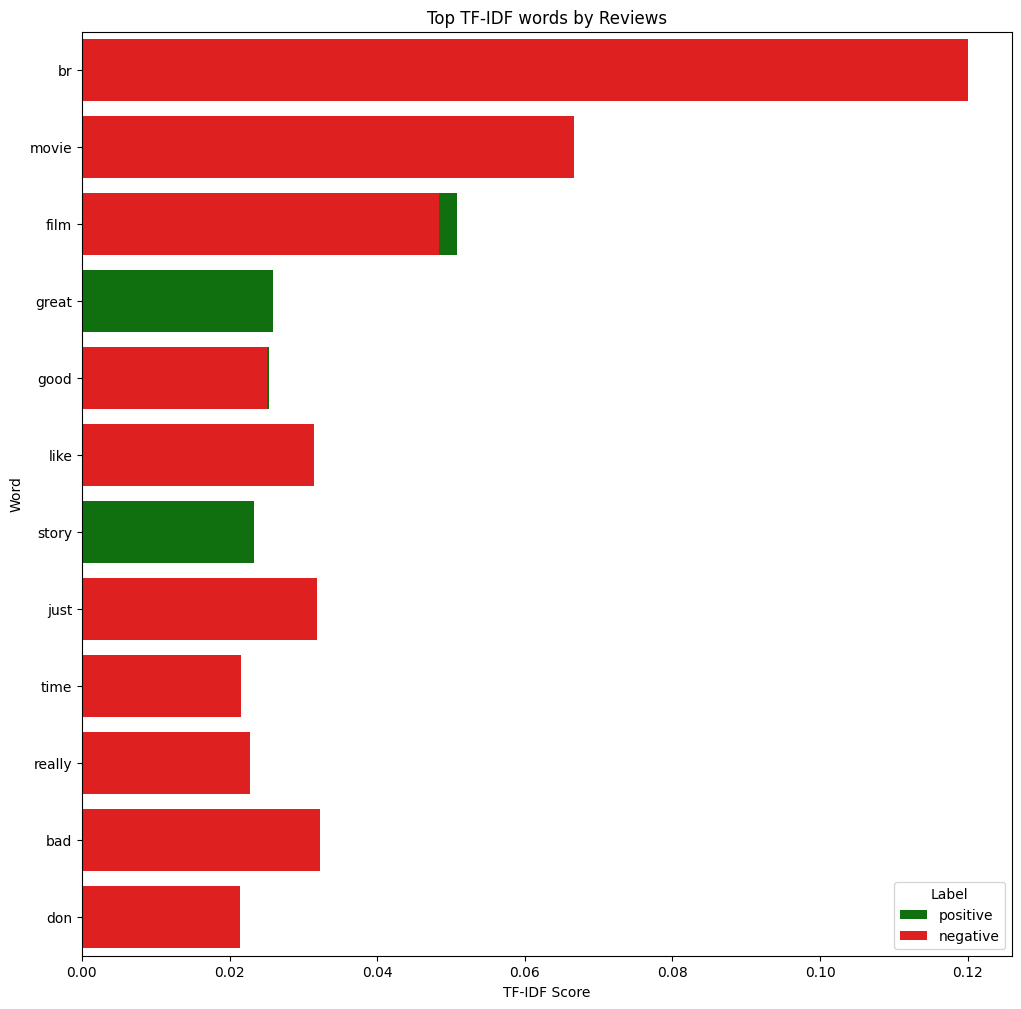

In [31]:
#TF-IDF Visualisation

tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,1),stop_words='english')

X = tfidf.fit_transform(train_df['review'])
feature_names = tfidf.get_feature_names_out()

pos_idx = train_df['label']==1
neg_idx = train_df['label']==0

X_pos = X[pos_idx.values]
X_neg = X[neg_idx.values]

pos_mean = np.asarray(X_pos.mean(axis=0)).ravel()
neg_mean = np.asarray(X_neg.mean(axis=0)).ravel()

top_n = 10

pos_top_idx = pos_mean.argsort()[-top_n:][::-1]
neg_top_idx = neg_mean.argsort()[-top_n:][::-1]

pos_top_words = [(feature_names[i],pos_mean[i]) for i in pos_top_idx]
neg_top_words = [(feature_names[i],neg_mean[i]) for i in neg_top_idx]

print("Top positive TF-IDF words:")
for word,score in pos_top_words:
  print(f"{word}:{score:.4f}")

print("Top negative TF-IDF words:")
for word,score in neg_top_words:
  print(f"{word}:{score:.4f}")

#Heatmap

df_heat = pd.DataFrame({"word":[w for w,s in pos_top_words] + [w for w,s in neg_top_words],
                        "score":[s for w,s in pos_top_words] + [s for w,s in neg_top_words],
                        "Label":["positive"]*top_n+["negative"]*top_n})

plt.figure(figsize=(12,12))
sns.barplot(data=df_heat,y="word",x="score",hue="Label",dodge=False,palette=["green","red"])
plt.title("Top TF-IDF words by Reviews")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()

**EDA SUMMARY**

Reference:
keras tutorial
ciattion
https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/

https://www.geeksforgeeks.org/deep-learning/keras-tuner-for-hyperparameter-optimization/

https://www.numberanalytics.com/blog/gru-text-classification

https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

https://keras.io/api/layers/convolution_layers/convolution1d/

**Data Preprocessing and Cleaning:**

In [12]:
#Function to strip HTML tags and punctuations

def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  removed_html = tf.strings.regex_replace(lowercase,'<br/>','')
  #removed_html = tf.strings.regex_replace('[^A-Za-z]','')
  #removed_html = tf.strings.regex_replace("\s+",'')
  return tf.strings.regex_replace(removed_html,f'[{re.escape(string.punctuation)}]','')

max_features = 10000 #Maximum Vocabulary size
sequence_length = 250  #Pad reviews

#Create Vectorizer
vectorize_layer = TextVectorization(standardize = custom_standardization,
                                    max_tokens=max_features,
                                    output_mode='int',
                                    output_sequence_length=sequence_length)

#Adapt on Training text only
train_text = raw_train_ds.map(lambda x,y:x)
vectorize_layer.adapt(train_text)

#Apply vectorization to all datasets
def vectorize_text(text,label):
  text = tf.expand_dims(text,-1)
  return vectorize_layer(text),label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

#Optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model Building and Interpretation:

# BaseLine Model:

In [74]:
#Baseline Model:

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

model = keras.Sequential([layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.GlobalAveragePooling1D(), #average all the wordvectorsin teh sequence
                          layers.Dense(16,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

#Compile the model

model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history = model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss,val_acc = model.evaluate(val_ds)
print('Validation Accuracy',val_acc)
print('Validation Loss',val_loss)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6270 - loss: 0.6405 - val_accuracy: 0.8292 - val_loss: 0.3937
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8516 - loss: 0.3507 - val_accuracy: 0.8500 - val_loss: 0.3396
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8893 - loss: 0.2741 - val_accuracy: 0.8634 - val_loss: 0.3194
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9078 - loss: 0.2340 - val_accuracy: 0.8714 - val_loss: 0.3103
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9208 - loss: 0.2057 - val_accuracy: 0.8784 - val_loss: 0.3006
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8771 - loss: 0.2928
Validation Accuracy 0.8784000277519226
Validation Loss 0.30062198638916016


**Evaluation Metrics (Baseline Model):**

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8771 - loss: 0.2928
Validation Accuracy 0.8784000277519226
Validation Loss 0.30062198638916016
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━

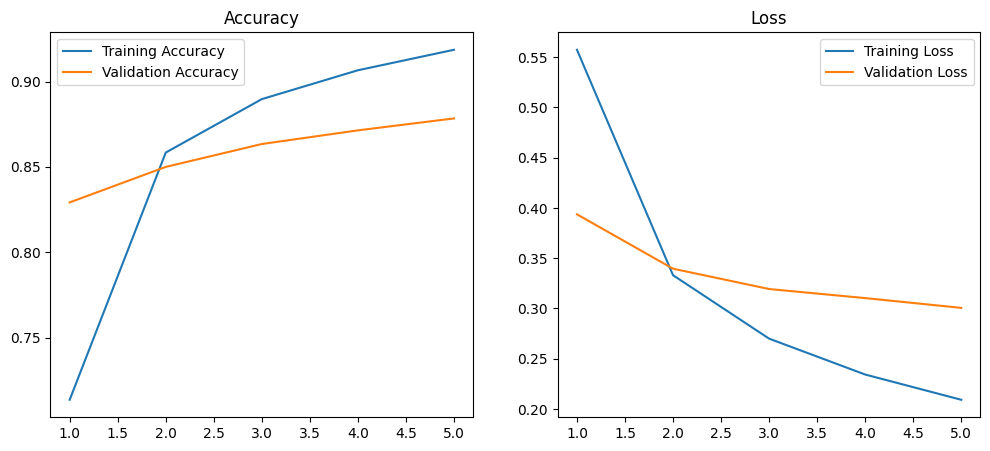

In [76]:
#Baseline Evaluation Metrics
val_loss_baseline,val_acc_baseline = model.evaluate(val_ds)
print('Validation Accuracy',val_acc_baseline)
print('Validation Loss',val_loss_baseline)

y_true_baseline=[]
y_pred_baseline=[]

for text_batch,label_batch in val_ds:
  preds = model.predict(text_batch)
  y_true_baseline.extend(label_batch.numpy())
  y_pred_baseline.extend((preds>0.5).astype('int32'))

cm_baseline = confusion_matrix(y_true_baseline,y_pred_baseline)
print(cm_baseline)

print(classification_report(y_true_baseline,y_pred_baseline))

history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()


**Baseline Summary:**

The accuracy of the baseline model is 0.85 which is good for a baseline model.This can be used as a benchmark to compare with the other models.

Model is good at identifying negative reviews than positive reviews.(TN - )Likely to Miss positive reviews(Higher FN)

This is confirmed in the classification Report summary.Negative reviews have higher recall and F1 score than the positive reviews (0 - 0.86, 1 - 0.84)

**Acccuracy Plot:**

Training accuracy climbs steadily after 0.85 and it reaches 0.925.Validation accuracy reaches around 0.85.Looks like overfitting which is natural for baseline model.

**Loss Plot:**

Training Loss is very high initially and then decreases.
Validation loss remains around 0.3 which confirms the overfitting pattern.

Baseline models overfits which is normal and this can be used as a base for other models.

# BiLSTM:

BiLSTM captures the information both forward and backward thereby capturing more contextual information.It is good at capturing negation,contrast etc.(like 'Not Good').

In [31]:
#Used the same parameters I have used in baseline for comparison

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.Bidirectional(layers.LSTM(64,return_sequences=False)) ,
                          layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history_bilstm = bilstm_model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss_bilstm,val_acc_bilstm = bilstm_model.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm)
print('Val Loss',val_loss_bilstm)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6596 - loss: 0.5865 - val_accuracy: 0.8134 - val_loss: 0.4303
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8452 - loss: 0.3771 - val_accuracy: 0.7328 - val_loss: 0.5267
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8420 - loss: 0.3607 - val_accuracy: 0.8650 - val_loss: 0.3317
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9165 - loss: 0.2264 - val_accuracy: 0.8606 - val_loss: 0.3524
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9383 - loss: 0.1729 - val_accuracy: 0.8616 - val_loss: 0.4160
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8568 - loss: 0.4210
Val Accuracy 0.8615999817848206
Val Loss 0.41596123576164246


In [13]:
#Used the same parameters I have used in baseline for comparison
#Due to overfitting, have added regularization

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model_1 = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.3),

    layers.Bidirectional(layers.LSTM(32,dropout=0.3,recurrent_dropout=0.3)) ,
    layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model_1.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
#Train Model

history_bilstm_1 = bilstm_model_1.fit(train_ds,validation_data=val_ds,epochs=5,callbacks=[early_stop])

#Evaluate
val_loss_bilstm_1,val_acc_bilstm_1 = bilstm_model_1.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm_1)
print('Val Loss',val_loss_bilstm_1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 660s 1s/step - accuracy: 0.5836 - loss: 0.6582 - val_accuracy: 0.7624 - val_loss: 0.5019
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.7686 - loss: 0.4958 - val_accuracy: 0.8050 - val_loss: 0.4529
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.8208 - loss: 0.4308 - val_accuracy: 0.8184 - val_loss: 0.4159
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - accuracy: 0.8527 - loss: 0.3626 - val_accuracy: 0.8096 - val_loss: 0.4157
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 664s 1s/step - accuracy: 0.8700 - loss: 0.3329 - val_accuracy: 0.7758 - val_loss: 0.4931
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.8121 - loss: 0.4150
Test Accuracy 0.8095999956130981
Test Loss 0.4156835377216339


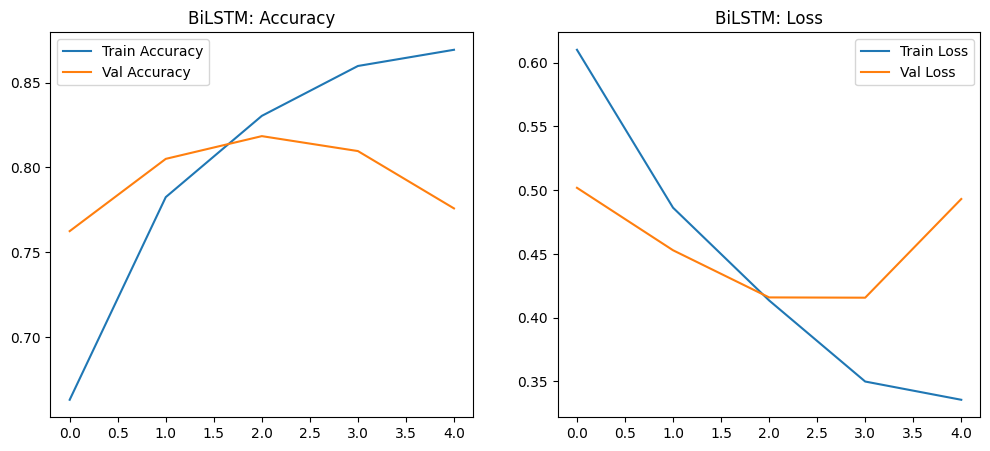

In [16]:
#Training Curve:

#BiLSTM Training Curve

acc_bilstm = history_bilstm_1.history['accuracy']
val_acc_bilstm = history_bilstm_1.history['val_accuracy']
loss_bilstm = history_bilstm_1.history['accuracy']
val_loss_bilstm = history_bilstm_1.history['val_loss']

epochs_bilstm = range(1,len(acc_bilstm)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_bilstm_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm_1.history['val_accuracy'], label='Val Accuracy')
plt.title('BiLSTM: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_bilstm_1.history['loss'], label='Train Loss')
plt.plot(history_bilstm_1.history['val_loss'], label='Val Loss')
plt.title('BiLSTM: Loss')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      2462
           1       0.79      0.85      0.82      2538

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000



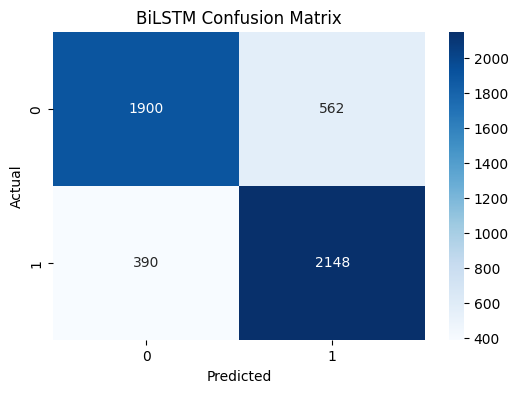

In [19]:
#Evaluation Metric:

#Classification Report
y_true_bilstm = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_bilstm = bilstm_model_1.predict(val_ds)
y_pred_bilstm = (y_pred_probs_bilstm > 0.5).astype("int32")

print(classification_report(y_true_bilstm, y_pred_bilstm))

#Confusion Matrix

cm_bilstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")
plt.show()

In [23]:
#Hyperparameter Tuning BiLSTM

def build_model_bilstm(bilstm):
    # 1. Tune the number of units in the LSTM layer
    # Choose an optimal value between 32-128
    bilstm_units = bilstm.Int('units', min_value=32, max_value=128, step=32)

    # 2. Tune the dropout rate
    bilstm_dropout = bilstm.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)

    # 3. Tune the learning rate
    bilstm_learning_rate = bilstm.Choice('learning_rate', values=[1e-3, 1e-4])

    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
        layers.SpatialDropout1D(0.3),

        # Removed recurrent_dropout for CuDNN speed
        layers.Bidirectional(layers.LSTM(units=bilstm_units, dropout=bilstm_dropout)),

        layers.Dense(bilstm_units, activation='relu'),
        layers.Dropout(bilstm_dropout),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=bilstm_learning_rate),
        loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    # Initialize the Tuner (Hyperband is efficient)
    tuner_bilstm = kt.Hyperband(
        build_model_bilstm,
        objective='val_accuracy',
        max_epochs=5,
        factor=3,
        directory='my_dir',
        project_name='imdb_bilstm_tuning'
    )
    
    # Early stopping to prevent overfitting
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    
    # Start searching
    tuner_bilstm.search(train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stop],verbose=2)
    
    # Get the best model
    best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]



Trial 30 Complete [00h 01m 50s]
val_accuracy: 0.8799999952316284

Best val_accuracy So Far: 0.8799999952316284
Total elapsed time: 00h 33m 09s


In [71]:

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]

final_bilstm_model = tuner_bilstm.hypermodel.build(best_hps_bilstm)

history_bilstm_tuned = final_bilstm_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=5, 
    callbacks=[early_stop],
    verbose=2
)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 - 21s - 33ms/step - accuracy: 0.5858 - loss: 0.6528 - val_accuracy: 0.8050 - val_loss: 0.4447
Epoch 2/5
625/625 - 18s - 29ms/step - accuracy: 0.8390 - loss: 0.3732 - val_accuracy: 0.8592 - val_loss: 0.3294
Epoch 3/5
625/625 - 18s - 29ms/step - accuracy: 0.8841 - loss: 0.2894 - val_accuracy: 0.8676 - val_loss: 0.3083
Epoch 4/5
625/625 - 18s - 28ms/step - accuracy: 0.9056 - loss: 0.2485 - val_accuracy: 0.8698 - val_loss: 0.3044
Epoch 5/5
625/625 - 18s - 28ms/step - accuracy: 0.9168 - loss: 0.2214 - val_accuracy: 0.8722 - val_loss: 0.3123


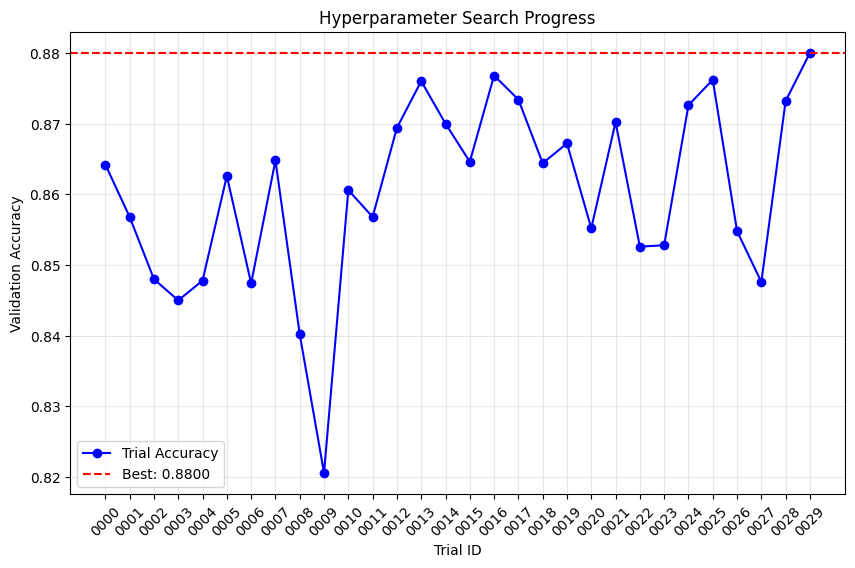

In [24]:
# 1. Get all trials from the oracle
all_trials = tuner_bilstm.oracle.trials.values()

# 2. Filter out trials that were interrupted (score is None)
complete_trials = [t for t in all_trials if t.score is not None]

# 3. Sort them by Trial ID so the graph follows the timeline
complete_trials.sort(key=lambda x: int(x.trial_id))

# 4. Extract IDs and Scores
trial_ids = [t.trial_id for t in complete_trials]
trial_scores = [t.score for t in complete_trials]

# 5. Plot
plt.figure(figsize=(10, 6))
plt.plot(trial_ids, trial_scores, marker='o', linestyle='-', color='b', label='Trial Accuracy')
plt.axhline(y=max(trial_scores), color='r', linestyle='--', label=f'Best: {max(trial_scores):.4f}')
plt.title('Hyperparameter Search Progress')
plt.xlabel('Trial ID')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
#Evaluation Metric for the best model


best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]

y_true_bilstm_tuned = np.concatenate([y for x,y in test_ds],axis=0)
y_pred_probs_bilstm_tuned = best_model_bilstm.predict(test_ds)
y_pred_bilstm_tuned = (y_pred_probs_bilstm_tuned > 0.5).astype("int32")

print("=== Final Evaluation Report: BiLSTM Model===")
print(classification_report(y_true_bilstm_tuned,y_pred_bilstm_tuned,target_names=['Negative','Positive']))

#Best Hyperparameters

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]


782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
=== Final Evaluation Report: BiLSTM Model===
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86     12500
    Positive       0.88      0.84      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000




 === Optimized Best Hyperparameters ===
LSTM Units: 96
Dropout Rate: 0.2
Learning Rate: 0.0001


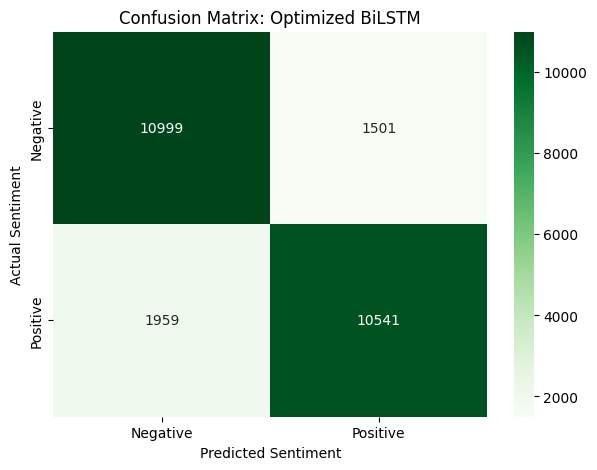

In [26]:
print("\n === Optimized Best Hyperparameters ===")
print(f"LSTM Units: {best_hps_bilstm.get('units')}")
print(f"Dropout Rate: {best_hps_bilstm.get('dropout')}")
print(f"Learning Rate: {best_hps_bilstm.get('learning_rate')}")

#Confusion Matrix

cm_bilstm_tuned = confusion_matrix(y_true_bilstm_tuned, y_pred_bilstm_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_bilstm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Optimized BiLSTM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# 1D CNN:
While BiLSTM reads word by word in both the directions,1D CNN uses filers to slide across the sentence to pick the patterns.

**Architecture:**

*   Embedding Layer - Turns words into vectors
*   Convolution Layer - Learns local patters(n-grams)
*   Global MaxPooling - Pickts the most important feature from the window
*   Dense Layer - To learn complex patterns
*   Dropout - Reduce overfitting
*   Dense Layer - Makes the final prediction



In [62]:
#1DCNN

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#1DCNN model
cnn_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.2),
    layers.Conv1D(filters=64,kernel_size=5,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)) ,
    layers.GlobalMaxPooling1D(),
    layers.Dense(64,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

cnn_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
early_stop_cnn = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2)
history_cnn_standard = cnn_model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop_cnn])
cnn_model.summary()

#Evaluate
val_loss_cnn,val_acc_cnn = cnn_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_cnn)
print('CNN Val Loss',val_loss_cnn)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6233 - loss: 0.6512 - val_accuracy: 0.8312 - val_loss: 0.4090
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8569 - loss: 0.3708 - val_accuracy: 0.8556 - val_loss: 0.3747
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9198 - loss: 0.2474 - val_accuracy: 0.8660 - val_loss: 0.3810
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9602 - loss: 0.1600 - val_accuracy: 0.8616 - val_loss: 0.4334


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 246, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,309 (14.93 MB)

 Trainable params: 1,304,769 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,540 (9.95 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.4342
CNN Val Accuracy 0.8615999817848206
CNN Val Loss 0.43341049551963806


The 1D CNN model show signs of overfitting .The training loss starts at 0.65 and decreases to 0.16 while the validation loss increases from 0.42 to 0.40.This indicates that the model begins to capture noise specific to the training set rather than broad sentiment patterns.

Early stopping is used to stop at the moment the validation loss starts improving.

Next,I am going to use keras Tuner find the best set of hyperparameters of 1D CNN model.



*   Spatial Dropout - 0.1,0.2,0.3,0.4

*   Filters = 32,64,96,128
*   Kernel_size = 3,5,7


*   List item



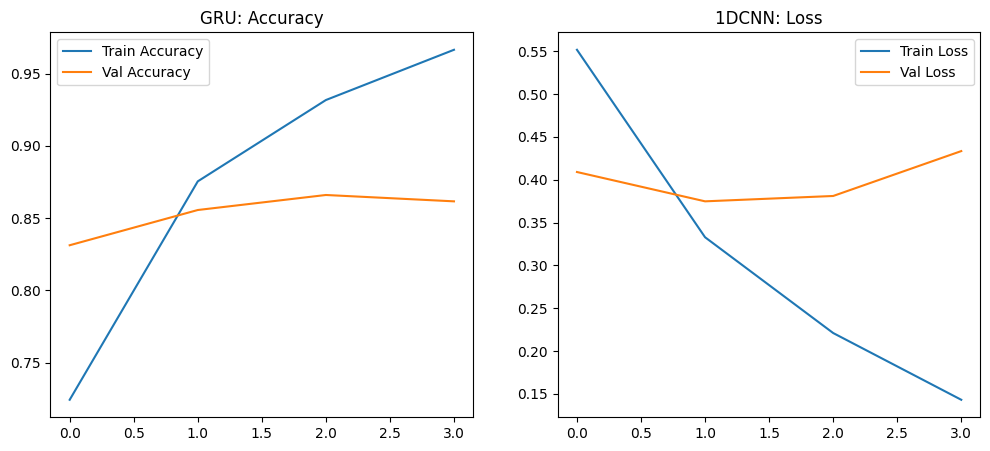

In [63]:
#1DCNN Training Curve

acc_cnn = history_cnn_standard.history['accuracy']
val_acc_cnn = history_cnn_standard.history['val_accuracy']
loss_cnn = history_cnn_standard.history['accuracy']
val_loss_cnn = history_cnn_standard.history['val_loss']

epochs = range(1,len(acc_cnn)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn_standard.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_standard.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn_standard.history['loss'], label='Train Loss')
plt.plot(history_cnn_standard.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      2462
           1       0.85      0.88      0.87      2538

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



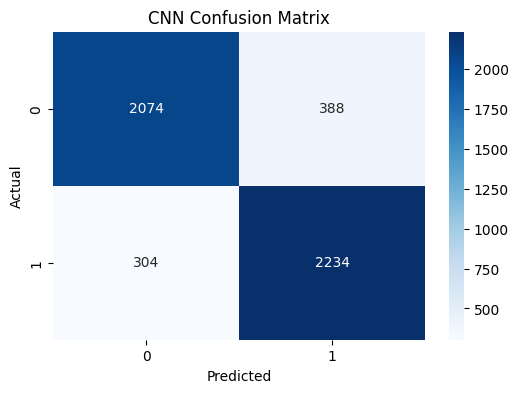

In [64]:
#Classification Report
y_true_cnn = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn = cnn_model.predict(val_ds)
y_pred_cnn = (y_pred_probs_cnn > 0.5).astype("int32")

print(classification_report(y_true_cnn, y_pred_cnn))

#Confusion Matrix

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## **Analysis:**

**Accuracy Graph**

*   Training accuracy starts very low and becomes closer to 1 by last epochs.
*   Validation accuracy begina at 85% , briefly increases a bit to 87% and then almost remains the same till the last epochs.
*   This means that the model is memorizing and it will work only on the training data and not on the unseen validation data.

**Loss Graph:**

*   Training Loss decreases rapidly from 0.5 to near ~0 , which shows almost perfect training accuracy.
*   Validation loss, on the other hand, starts low and then increases across epochs, confirming that additional training will increase it further.
*   This indicates a sign of overfitting.

Keras Tuner gave the best possible hyperparamater combination based on the highest Validation accuracy.But from the above 2 plots, we found that there is a classic sign of overfitting.So, picking the epoch with the lowest validation loss which tells when to stop training for a given hyperparameter set.






In [31]:
#In the same hyperparameter tuning I used earlier, am going to change the objective to val_loss

def build_cnn_hypermodel(cnn):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=cnn.Float('spatial_dropout', min_value=0.1, max_value=0.4, step=0.1)
    ))

    #Conv1D Filters and Kernel Size
    model.add(layers.Conv1D(
        filters=cnn.Int('filters', min_value=32, max_value=128, step=32),
        kernel_size=cnn.Choice('kernel_size', values=[3, 5, 7]),
        activation='relu'
    ))

    model.add(layers.GlobalMaxPooling1D())

    #Dense Layer Units
    model.add(layers.Dense(
        units=cnn.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    model.add(layers.Dropout(cnn.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = cnn.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_cnn = kt.Hyperband(
    build_cnn_hypermodel,
    objective='val_loss',
    max_epochs=10,
    factor=3,
    directory='cnn_tuning_dir',
    project_name='imdb_cnn_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

tuner_cnn.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])

# Get the best hyperparameters
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Filters: {best_hps_cnn.get('filters')}")
print(f"Optimal Kernel Size: {best_hps_cnn.get('kernel_size')}")
print(f"Optimal Spatial Dropout: {best_hps_cnn.get('spatial_dropout')}")

# Build the model with the best hyperparameters and train it
best_cnn_model = tuner_cnn.hypermodel.build(best_hps_cnn)
history_cnn = best_cnn_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])


Trial 30 Complete [00h 00m 13s]
val_loss: 0.32685279846191406

Best val_loss So Far: 0.31854915618896484
Total elapsed time: 00h 04m 58s
Optimal Filters: 64
Optimal Kernel Size: 5
Optimal Spatial Dropout: 0.1
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6513 - loss: 0.5817 - val_accuracy: 0.8308 - val_loss: 0.3732
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8826 - loss: 0.2777 - val_accuracy: 0.8642 - val_loss: 0.3297
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9524 - loss: 0.1325 - val_accuracy: 0.8748 - val_loss: 0.3584
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9866 - loss: 0.0463 - val_accuracy: 0.8736 - val_loss: 0.4328


In [37]:
#Get best hyperparameters from tuner
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

#uild and train a model with hyperparameters
best_model_cnn = tuner_cnn.hypermodel.build(best_hps_cnn)

history_cnn = best_model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,              # or more, with EarlyStopping if you like
    callbacks=[stop_early]
)

#val_loss and corresponding val_accuracy
val_loss_history_cnn = history_cnn.history["val_loss"]
val_acc_history_cnn  = history_cnn.history["val_accuracy"]

best_epoch_cnn = int(np.argmin(val_loss_history_cnn))  # index of lowest val_loss
best_val_loss_cnn = float(val_loss_history_cnn[best_epoch_cnn])
best_val_acc_cnn  = float(val_acc_history_cnn[best_epoch_cnn])

print("Best epoch:", best_epoch_cnn + 1)
print("Best val_loss:", best_val_loss_cnn)
print("Best val_accuracy:", best_val_acc_cnn)


cnn_result = {
    "model_name": "1D_CNN_tuned",
    "best_epoch": best_epoch_cnn + 1,
    "best_val_loss": best_val_loss_cnn,
    "best_val_accuracy": best_val_acc_cnn,
    "filters": best_hps_cnn.get("filters"),
    "kernel_size": best_hps_cnn.get("kernel_size"),
    "spatial_dropout": best_hps_cnn.get("spatial_dropout"),
    "dense_units": best_hps_cnn.get("dense_units"),
    "dropout": best_hps_cnn.get("dropout"),
    "learning_rate": best_hps_cnn.get("learning_rate"),
}

print(cnn_result)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6560 - loss: 0.5812 - val_accuracy: 0.8470 - val_loss: 0.3543
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8893 - loss: 0.2750 - val_accuracy: 0.8772 - val_loss: 0.3038
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9575 - loss: 0.1249 - val_accuracy: 0.8824 - val_loss: 0.3494
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9884 - loss: 0.0411 - val_accuracy: 0.8804 - val_loss: 0.4265
Best epoch: 2
Best val_loss: 0.30383631587028503
Best val_accuracy: 0.8772000074386597
{'model_name': '1D_CNN_tuned', 'best_epoch': 2, 'best_val_loss': 0.30383631587028503, 'best_val_accuracy': 0.8772000074386597, 'filters': 64, 'kernel_size': 5, 'spatial_dropout': 0.1, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001}


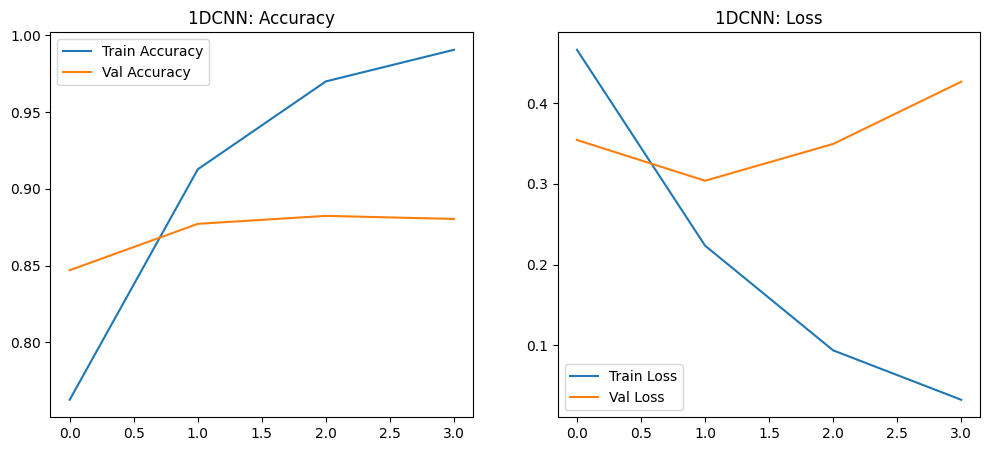

In [39]:
#1DCNN Hyperparameter Tuned Training Curve

acc_cnn_tuned = history_cnn.history['accuracy']
val_acc_cnn_tuned = history_cnn.history['val_accuracy']
loss_gru = history_cnn.history['accuracy']
val_loss_gru = history_cnn.history['val_loss']

epochs = range(1,len(acc_cnn_tuned)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1DCNN: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


# Evaluation Metrics:

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      2462
           1       0.88      0.88      0.88      2538

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



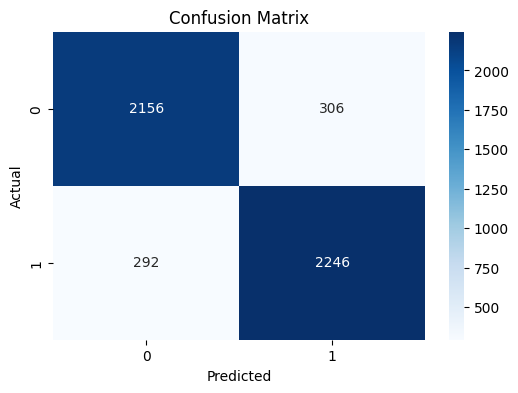

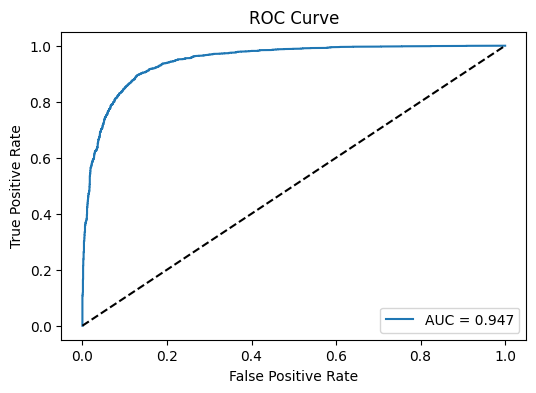

In [40]:
y_true_cnn_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn_tuned = best_model_cnn.predict(val_ds)
y_pred_cnn_tuned = (y_pred_probs_cnn_tuned > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true_cnn_tuned, y_pred_cnn_tuned))

# Confusion Matrix
cm_cnn_tuned = confusion_matrix(y_true_cnn_tuned, y_pred_cnn_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#ROC AUC Curve

fpr_cnn_tuned, tpr_cnn_tuned, thresholds_cnn_tuned = roc_curve(y_true_cnn_tuned, y_pred_probs_cnn_tuned)
roc_auc_cnn_tuned = auc(fpr_cnn_tuned, tpr_cnn_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr_cnn_tuned, tpr_cnn_tuned, label=f"AUC = {roc_auc_cnn_tuned:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

1D CNN Summary:



*   Based on the chosen architecture, I first built a 1D‑CNN model and evaluated its performance using validation accuracy. The results indicated clear signs of overfitting.

*   Next, I used Keras Tuner to search for optimal hyperparameters using validation accuracy as the objective.
*   Although the tuner identified a configuration with improved validation accuracy, the training curves still showed overfitting.


*   To address this, I ran Keras Tuner again—this time optimizing for validation loss instead of accuracy. This approach produced a more stable model with better generalization.

*   Using the best hyperparameters identified through the val_loss‑based search, the following section summarizes the optimal hyperparameter combination and provides a brief performance report.
*   Best epoch: 8
Best val_loss: 0.30746176838874817
Best val_accuracy: 0.8744000196456909

{'model_name': '1D_CNN_tuned', 'best_epoch': 8, 'best_val_loss': 0.30746176838874817, 'best_val_accuracy': 0.8744000196456909, 'filters': 96, 'kernel_size': 7, 'spatial_dropout': 0.30000000000000004, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.0001}










# Gated Recurrent Networks: (GRU)

In [58]:
vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#GRU model
gru_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),

    GRU(64,dropout=0.2,recurrent_dropout=0.2),
    Dense(1,activation='sigmoid')
])

gru_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
history_gru_standard = gru_model.fit(train_ds,validation_data=val_ds,epochs=10,batch_size=64,callbacks=[stop_early])
gru_model.summary()

#Evaluate
val_loss_gru,val_acc_gru = gru_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_gru)
print('CNN Val Loss',val_loss_gru)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 395s 626ms/step - accuracy: 0.5049 - loss: 0.6934 - val_accuracy: 0.5122 - val_loss: 0.6968
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 391s 625ms/step - accuracy: 0.5414 - loss: 0.6899 - val_accuracy: 0.6550 - val_loss: 0.6783
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 390s 625ms/step - accuracy: 0.7110 - loss: 0.5655 - val_accuracy: 0.8006 - val_loss: 0.4396
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 391s 625ms/step - accuracy: 0.8544 - loss: 0.3395 - val_accuracy: 0.8622 - val_loss: 0.3262
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 391s 626ms/step - accuracy: 0.9169 - loss: 0.2171 - val_accuracy: 0.8640 - val_loss: 0.3273
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 388s 622ms/step - accuracy: 0.9466 - loss: 0.1506 - val_accuracy: 0.8598 - val_loss: 0.3605


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,915,077 (14.93 MB)

 Trainable params: 1,305,025 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,610,052 (9.96 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.8627 - loss: 0.3209
CNN Val Accuracy 0.8622000217437744
CNN Val Loss 0.326240211725235


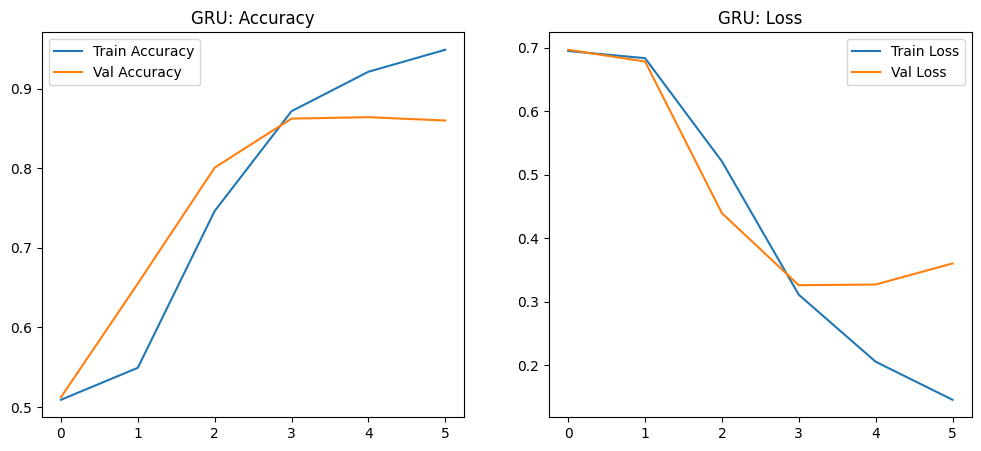

In [59]:
#GRU Training Curve

acc_gru = history_gru_standard.history['accuracy']
val_acc_gru = history_gru_standard.history['val_accuracy']
loss_gru = history_gru_standard.history['accuracy']
val_loss_gru = history_gru_standard.history['val_loss']

epochs = range(1,len(acc_gru)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_gru_standard.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru_standard.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_gru_standard.history['loss'], label='Train Loss')
plt.plot(history_gru_standard.history['val_loss'], label='Val Loss')
plt.title('GRU: Loss')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      2462
           1       0.89      0.83      0.86      2538

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



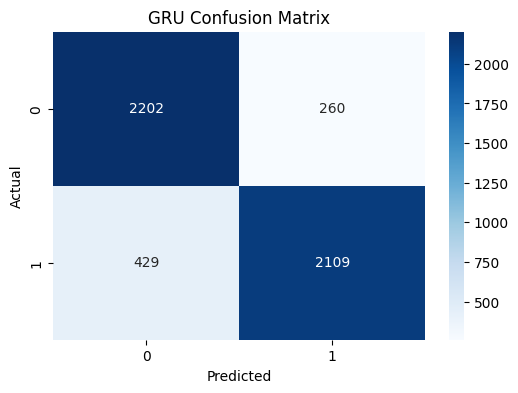

In [60]:
#Classification Report
y_true_gru = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru = gru_model.predict(val_ds)
y_pred_gru = (y_pred_probs_gru > 0.5).astype("int32")

print(classification_report(y_true_gru, y_pred_gru))

#Confusion Matrix

cm_gru = confusion_matrix(y_true_gru, y_pred_gru)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

Next, I performed hyper parameter tuning on the GRU model using keras Tuner.

*   rate = [0.1,0.2,0.3,0.4]
*   units = [32,64,128]
*   dropout = [0.2,0.3,0.5]
*   lr = [1e-3,5e-4,1e-4]

The Tuner will test multiple combinations and the best model will be selected based on the minimum validation loss.Early stoppping is used to restore best weights.



In [52]:
#Hypertuned GRU
#rate = [0.1,0.2,0.3,0.4]
#units = [32,64,128]
#dropout = [0.2,0.3,0.5]
#lr = [1e-3,5e-4,1e-4]

def build_gru_hypermodel(gru):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=gru.Float('spatial_dropout', min_value=0.1, max_value=0.2, step=0.1)
    ))

    units = gru.Choice("units",[32,64])
    dropout = gru.Choice("dropout",[0.2,0.3])

    model.add(layers.GRU(
        units,
        dropout=dropout,
        recurrent_dropout = dropout
    ))

    #Dense Layer Units
    model.add(layers.Dense(
        units=gru.Int('dense_units', min_value=32, max_value=64, step=32),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = gru.Choice('learning_rate', values=[1e-3,1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_gru = kt.RandomSearch(
    build_gru_hypermodel,
    objective='val_loss',
    max_trials=5,
    directory='gru_tuning',
    project_name='imdb_gru_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2,restore_best_weights=True)

tuner_gru.search(train_ds, validation_data=val_ds, epochs=3, callbacks=[stop_early])

# Get the best hyperparameters
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
best_hps_gru.values

print("Best Hyperparameters:")
print(f"Spatial Dropout: {best_hps_gru.get('spatial_dropout')}")
print(f"GRU Units: {best_hps_gru.get('units')}")
print(f"Dropout: {best_hps_gru.get('dropout')}")
print(f"Dense Units: {best_hps_gru.get('dense_units')}")
print(f"Learning Rate: {best_hps_gru.get('learning_rate')}")

# Build the model with the best hyperparameters and train it
best_gru_model = tuner_gru.hypermodel.build(best_hps_gru)
history_gru = best_gru_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])

val_loss_history_gru = history_gru.history["val_loss"]
best_epoch_gru = int(np.argmin(val_loss_history_gru))+ 1

gru_tuned_result = {
    "model_name": "GRU_tuned",
    "best_epoch": best_epoch_gru,
    "best_val_loss": float(min(val_loss_history_gru)),
    "best_val_accuracy": float(max(history_gru.history["val_accuracy"])),
    "embedding_dim": best_hps_gru.get("embedding_dim"),
    "units": best_hps_gru.get("units"),
    "dropout": best_hps_gru.get("dropout"),
    "dense_units": best_hps_gru.get("dense_units"),
    "learning_rate": best_hps_gru.get("learning_rate"),
}

print(gru_tuned_result)


Reloading Tuner from gru_tuning/imdb_gru_search/tuner0.json
Best Hyperparameters:
Spatial Dropout: 0.2
GRU Units: 128
Dropout: 0.3
Dense Units: 64
Learning Rate: 0.0001
Epoch 1/10
 29/625 ━━━━━━━━━━━━━━━━━━━━ 5:46 581ms/step - accuracy: 0.4851 - loss: 0.6934

KeyboardInterrupt: 

In [ ]:
#Loss and Accuracy Plot

acc_gru_tuned = history_gru.history['accuracy']
val_acc_gru_tuned = history_gru.history['val_accuracy']
loss_gru_tuned = history_gru.history['loss']
val_loss_gru_tuned = history_gru.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc_gru_tuned, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc_gru_tuned, 'r-', label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss_gru_tuned, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_gru_tuned, 'r-', label='Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Classification Report
y_true_gru_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru_tuned = gru_model.predict(val_ds)
y_pred_gru_tuned = (y_pred_probs > 0.5).astype("int32")

print(classification_report(y_true_gru_tuned, y_pred_gru_tuned))

#Confusion Matrix

cm_gru_tuned = confusion_matrix(y_true_gru_tuned, y_pred_gru_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

#ROC Curve

fpr_gru_tuned, tpr_gru_tuned, thresholds_gru_tuned = roc_curve(y_true_gru_tuned, y_pred_probs_gru_tuned)
roc_auc_gru_tuned = auc(fpr_gru_tuned, tpr_gru_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr_gru_tuned, tpr_gru_tuned, label=f"AUC = {roc_auc_gru_tuned:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [67]:
import json
import pickle
import os
import numpy as np
from sklearn.metrics import classification_report

def save_full_model_assets(model, history, name, val_ds):
    # Create directory
    folder = 'imdb_models'
    if not os.path.exists(folder): os.makedirs(folder)
    
    # 1. Save Model Architecture Summary as string
    summary_list = []
    model.summary(print_fn=lambda x: summary_list.append(x))
    with open(f'{folder}/{name}_summary.txt', 'w') as f:
        f.write("\n".join(summary_list))
    
    # 2. Save Training History (Acc, Loss for both Train & Val)
    with open(f'{folder}/{name}_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
        
    # 3. Generate and Save Detailed Metrics (Precision, Recall, F1)
    # Get true labels and predictions
    y_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_pred_probs = model.predict(val_ds)
    y_pred = (y_pred_probs > 0.5).astype("int32")
    
    # Get classification report as a dictionary
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # 4. Save a consolidated JSON for the comparison table
    metrics = {
        "model_name": name,
        "val_accuracy": report['accuracy'],
        "val_loss": history.history['val_loss'][-1],
        "precision": report['weighted avg']['precision'],
        "recall": report['weighted avg']['recall'],
        "f1_score": report['weighted avg']['f1-score']
    }
    
    with open(f'{folder}/{name}_metrics.json', 'w') as f:
        json.dump(metrics, f)
        
    # 5. Save the .keras model file
    model.save(f'{folder}/{name}_model.keras')
    print(f"All assets for {name} saved to {folder}/")

In [78]:
save_full_model_assets(cnn_model, history_cnn_standard, "CNN_standard", val_ds)
save_full_model_assets(best_model_cnn, history_cnn, "CNN_tuned", val_ds)
save_full_model_assets(gru_model, history_gru_standard, "GRU_Standard", val_ds)
#save_full_model_assets(best_gru_model, history_gru, "GRU_tuned", val_ds)
save_full_model_assets(bilstm_model_1, history_bilstm_1, "BiLSTM Standard",val_ds)
save_full_model_assets(final_bilstm_model, history_bilstm_tuned, "BiLSTM_tuned", val_ds)
save_full_model_assets(model, history, "Baseline", val_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
All assets for CNN_standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
All assets for CNN_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step
All assets for GRU_Standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step
All assets for BiLSTM Standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
All assets for BiLSTM_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
All assets for Baseline saved to imdb_models/


**BERT**

Citations:
TensorFlow Hub. (n.d.). BERT uncased English preprocessing model. https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

TensorFlow Hub. (n.d.). Small BERT: Uncased L-4 H-512 A-8. https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1

Devlin, J., Chang, M.‑W., Lee, K., & Toutanova, K. (2019). BERT: Pre‑training of deep bidirectional transformers for language understanding. Proceedings of NAACL‑HLT. https://arxiv.org/abs/1810.04805

TensoFlow:
Abadi, M., et al. (2016). TensorFlow: Large‑scale machine learning on heterogeneous systems. https://www.tensorflow.org/

TensorFlow Text:

TensorFlow Text. (n.d.). https://www.tensorflow.org/text

In [ ]:
#Choose BERT Variant

bert_preprocess_url = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
bert_encoder_url = "https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1"

#Preprocessing layer and BERT model layer

bert_preprocess_model = hub.KerasLayer(bert_preprocess_url)
bert_model = hub.KerasLayer(bert_encoder_url)


def build_classifier_bert_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')

    # Preprocessing: Converts raw text to BERT-ready tokens/masks
    preprocessing_layer = hub.KerasLayer(bert_preprocess_url, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)

    # Encoder: The actual BERT model
    encoder = hub.KerasLayer(bert_encoder_url, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)

    # BERT returns a dictionary; 'pooled_output' represents the entire sequence
    net = outputs['pooled_output']

    # Classification Head
    net = tf.keras.layers.Dropout(0.1)(net)
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)

    return tf.keras.Model(text_input, net)

model = build_classifier_bert_model()

In [ ]:
loss = tf.keras.losses.binary_crossentropy()
metrics = tf.metrics.BinaryAccuracy()

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)

model.compile(optimizer=optimizer,
              loss=loss,
              metrics=metrics)

history = model.fit(raw_train_ds,validation_data=raw_val_ds,epochs=3)